# Calibration

Trying out new calibration method.
Using xy files generated from mzXML sum spectra (VisuCon samples), containing
data for IgG, IgA and IgM.

## Data preparation


In [116]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import numpy as np
import pandas as pd

# Make paths independent of whether Jupyter starts in the repository root
# or in the tests directory containing this notebook.
project_root = Path.cwd()
if not (project_root / "sweet_suite").is_dir():
    project_root = project_root.parent
if not (project_root / "sweet_suite").is_dir():
    raise FileNotFoundError("Could not locate the SweetSuite project root")
sys.path.insert(0, str(project_root))

from sweet_suite.mass_spectrometry.mass_spectrum import MassSpectrum

In [ ]:
xy_folder = project_root / "tests" / "xy_uncalibrated_sumspectra"

# NOTE: SES cluster calibrants act weird, so excluding may be better.
exclude_analytes_ref = False

if exclude_analytes_ref:
    analytes_ref_path = project_root / "tests" / "analytes_ref_noSEScalibrants.xlsx"
else:
    analytes_ref_path = project_root / "tests" / "analytes_ref.xlsx"

analytes_ref = pd.read_excel(analytes_ref_path)
ref_calibrants = analytes_ref[analytes_ref["calibrant"]]

BACKGROUND_MASS_WINDOW = 10.0
CALIBRATION_MASS_WINDOW = 0.2
CALIBRANT_SN_CUTOFF = 27

In [118]:
SUM_SPECTRUM_PATTERN = re.compile(
    r"^SumSpectrum_(?P<time>[^_]+)_(?P<time_window>[^_]+)_(?P<file_raw>.+)$"
)

def parse_sum_spectrum_path(path):
    match = SUM_SPECTRUM_PATTERN.fullmatch(Path(path).stem)
    return (
        float(match["time"]),
        float(match["time_window"]),
        match["file_raw"],
    )

def read_xy_file(path):
    return np.loadtxt(path)

In [119]:
# Check number of sum spectra created per mzXML.
xy_paths_by_file = {}
for path in xy_folder.glob("*.xy"):
    time, time_window, file_raw = parse_sum_spectrum_path(path)
    xy_paths_by_file.setdefault(file_raw, []).append(
        (time, time_window, path)
    )

for xy_paths in xy_paths_by_file.values():
    xy_paths.sort(key=lambda item: (item[0], item[1]))

group_summary = pd.DataFrame(
    {
        "raw_file": file_raw,
        "plate_position": file_raw.rsplit("-", 1)[-1],
        "sum_spectra": len(xy_paths),
    }
    for file_raw, xy_paths in sorted(xy_paths_by_file.items())
)

group_summary

,raw_file,plate_position,sum_spectra
0,aligned_2026GLY00034-PL01_B09,PL01_B09,12
1,aligned_2026GLY00034-PL01_D06,PL01_D06,12
2,aligned_2026GLY00034-PL01_E01,PL01_E01,12
3,aligned_2026GLY00034-PL01_G12,PL01_G12,12
4,aligned_2026GLY00034-PL02_B07,PL02_B07,12
5,aligned_2026GLY00034-PL02_E01,PL02_E01,12
6,aligned_2026GLY00034-PL02_F09,PL02_F09,12
7,aligned_2026GLY00034-PL02_G04,PL02_G04,12
8,aligned_2026GLY00034-PL02_H11,PL02_H11,12


We can now replicate part of the batch process.

In [120]:
mass_spectra = {}

# Loop over raw file (indicating mzXML file) and corresponding xy files
for file_raw, xy_paths in sorted(xy_paths_by_file.items()):

    file_mass_spectra = []  # To collect mass spectrum instances for this mzXML

    # Loop over xy sum spectra
    for time, time_window, path in xy_paths:

        # Select calibrants in this retention time range
        calibrants_df = (
            ref_calibrants[
                (ref_calibrants["time"] == time)
                & (ref_calibrants["time_window"] == time_window)
            ]
            .assign(
                charge=lambda frame: (
                    frame["peak"].str.split("_").str[1].astype(int)
                )
            )
            [["mz", "charge", "mz_window"]]
        )

        # Create a MassSpectrum instance and add to list.
        file_mass_spectra.append(
            MassSpectrum(
                name=path.stem,
                file_raw=file_raw,
                data_uncalibrated=read_xy_file(path),
                background_mass_window=BACKGROUND_MASS_WINDOW,
                calibration_mass_window=CALIBRATION_MASS_WINDOW,
                calibrants_df=calibrants_df,
                time=time,
                time_window=time_window,
            )
        )

    # Add list of Mass Spectra for this mzXML file to the dictionary.
    mass_spectra[file_raw] = file_mass_spectra


# Inspect number of spectra per mzXML as a sanity check.
{file_raw: len(spectra) for file_raw, spectra in mass_spectra.items()}

{'aligned_2026GLY00034-PL01_B09': 12,
 'aligned_2026GLY00034-PL01_D06': 12,
 'aligned_2026GLY00034-PL01_E01': 12,
 'aligned_2026GLY00034-PL01_G12': 12,
 'aligned_2026GLY00034-PL02_B07': 12,
 'aligned_2026GLY00034-PL02_E01': 12,
 'aligned_2026GLY00034-PL02_F09': 12,
 'aligned_2026GLY00034-PL02_G04': 12,
 'aligned_2026GLY00034-PL02_H11': 12}

In [121]:
# Collect all calibrants per mzXML file.
calibrants_dict = {}

for file_raw, file_mass_spectra in mass_spectra.items():
    
    file_calibrants = []

    for ms in file_mass_spectra:
        for cal in ms.calibrants:
            if cal.signal_to_noise > CALIBRANT_SN_CUTOFF:
                file_calibrants.append(
                    {
                        "time": cal.time,
                        "signal_to_noise": cal.signal_to_noise,
                        "mz_exact": cal.mz_exact,
                        "mz_observed": cal.mz_observed,
                    }
                )

    calibrants_dict[file_raw] = file_calibrants

pd.DataFrame(
    {"raw_file": file_raw, "calibrants": len(values)}
    for file_raw, values in calibrants_dict.items()
)

,raw_file,calibrants
0,aligned_2026GLY00034-PL01_B09,30
1,aligned_2026GLY00034-PL01_D06,44
2,aligned_2026GLY00034-PL01_E01,65
3,aligned_2026GLY00034-PL01_G12,48
4,aligned_2026GLY00034-PL02_B07,54
5,aligned_2026GLY00034-PL02_E01,70
6,aligned_2026GLY00034-PL02_F09,48
7,aligned_2026GLY00034-PL02_G04,59
8,aligned_2026GLY00034-PL02_H11,46


## Calibration methods
We now have a dictionary called `calibrants_dict`, which has a list
of calibrants for each mzXML file (this is the `calibrants` list in 
`batch_worker.py` line 790).

### Existing calibration model
We'll start by fitting the existing m/z-only calibration model, using a
quadratic fit, but with a small change. Instead of fitting exact m/z
values as a function of observed m/z, we'll fit the required m/z correction
$\Delta m/z = m/z_\text{exact} - m/z_\text{observed}$ as a function
of observed m/z:

$$ \Delta m/z = \beta_0 + \beta_1 \times m/z_\text{observed} + \beta_2 \times (m/z_\text{observed})^2 $$

The existing m/z values in the spectrum are then calibrated by adding the predicted correction:

$$ m/z_\text{calibrated} = m/z_\text{existing} + (\Delta m/z)_\text{correction}$$

This has a simple interpretation: the model predicts how much the observed m/z value should be shifted.

In [122]:
def calibration_fit_quadratic(calibrants: list[dict]) -> np.ndarray:
    """Fit a quadratic m/z calibration model.
    
    The model predicts the required m/z correction:

        mz_exact - mz_observed

    as a quadratic function of the observed m/z.

    Returns a NumPy array containing the polynomial coefficients in descending
    order: [quadratic, linear, intercept]
    """
    mz_observed = np.array(
        [
            calibrant["mz_observed"] 
            for calibrant in calibrants
        ],
        dtype=float
    )

    mz_delta = np.array(
        [
            calibrant["mz_exact"] - calibrant["mz_observed"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    fit = np.polyfit(
        x=mz_observed,
        y=mz_delta,
        deg=2
    )

    return fit

In [123]:
def plot_calibration_fit_quadratic(
    calibrants: list[dict],
    fit: np.ndarray,
    raw_file: str
) -> Figure:
    mz_observed = np.array(
        [
            calibrant["mz_observed"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    mz_delta = np.array(
        [
            calibrant["mz_exact"] - calibrant["mz_observed"]
            for calibrant in calibrants
        ]
    )

    # Get retention times to color the points by
    time = np.array(
        [
            calibrant["time"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    # Create evenly spaced m/z values for drawing smooth fitted curve
    mz_plot = np.linspace(
        mz_observed.min(),
        mz_observed.max(),
        500
    )

    # Apply the fit to the specified m/z values
    delta_fitted = np.polyval(fit, mz_plot)

    # Make figure
    figure, axis = plt.subplots()
    scatter = axis.scatter(
        mz_observed,
        mz_delta,
        c=time,
        cmap="turbo",
        s=45,
        edgecolor="black",
        linewidths=0.4
    )
    axis.plot(
        mz_plot,
        delta_fitted,
        label="Quadratic fit"
    )
    axis.axhline(0, linewidth=1, linestyle="--")
    axis.set_xlabel(r"Observed $m/z$")
    axis.set_ylabel(r"Required correction $\Delta m/z$")
    axis.set_title(f"Quadratic m/z calibration fit\n{raw_file}")
    axis.legend()
    colorbar = figure.colorbar(scatter, ax=axis)
    colorbar.set_label("Retention time")
    figure.tight_layout()

    return figure

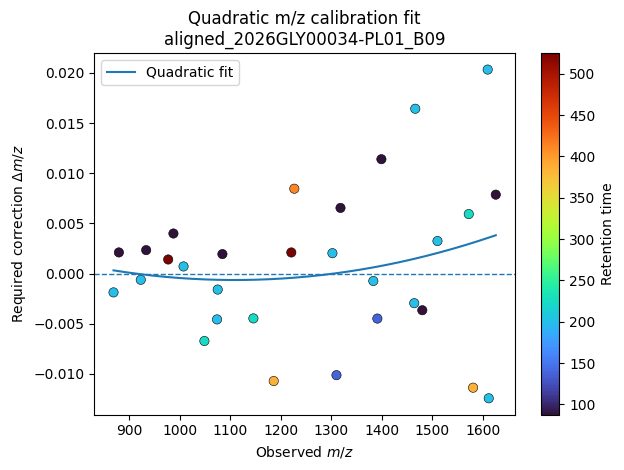

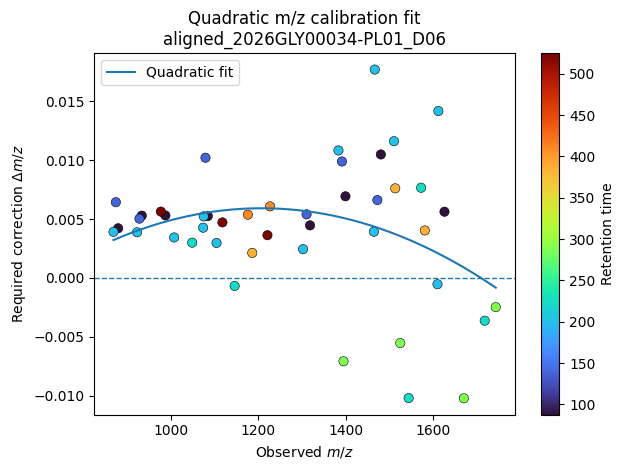

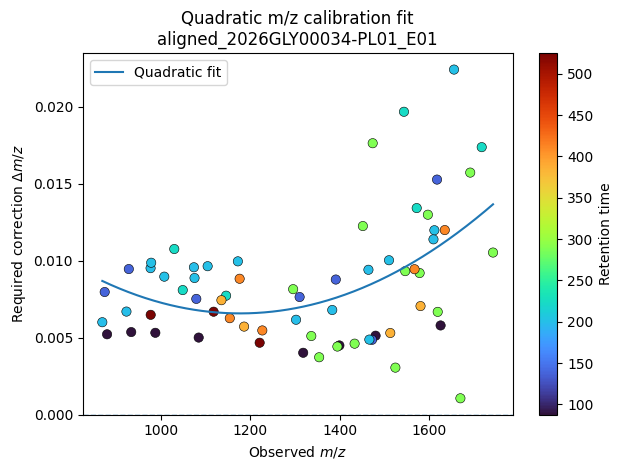

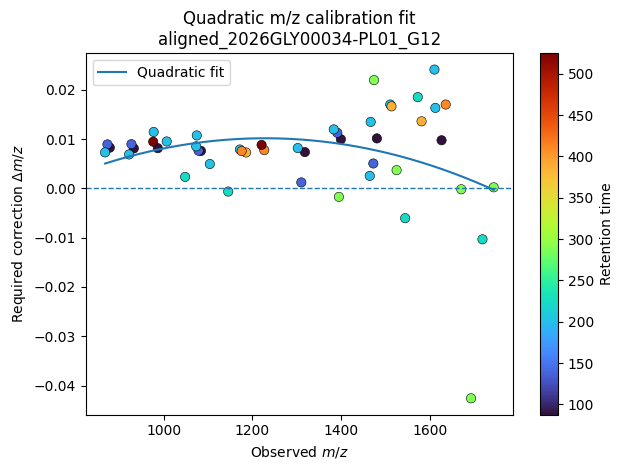

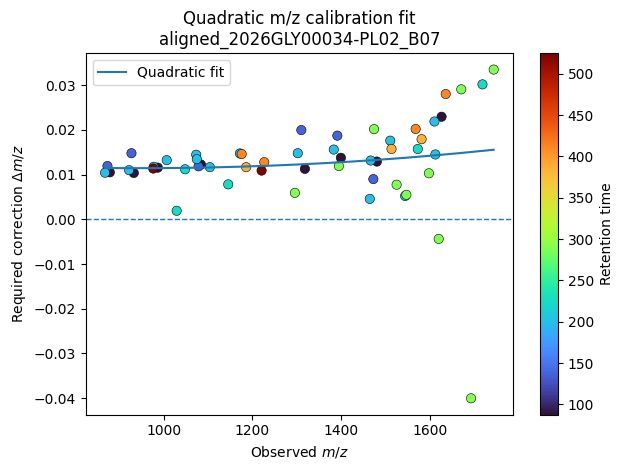

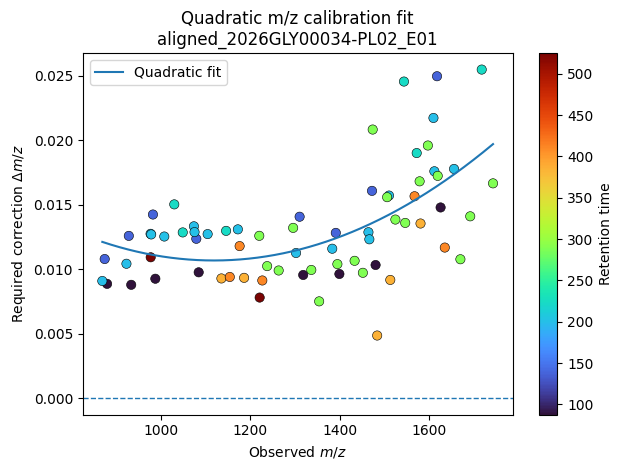

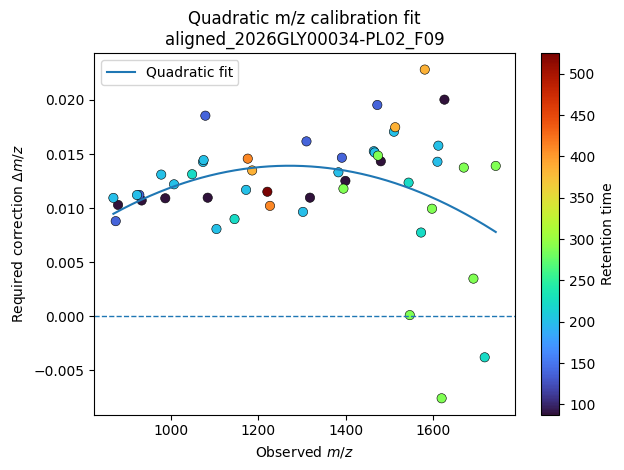

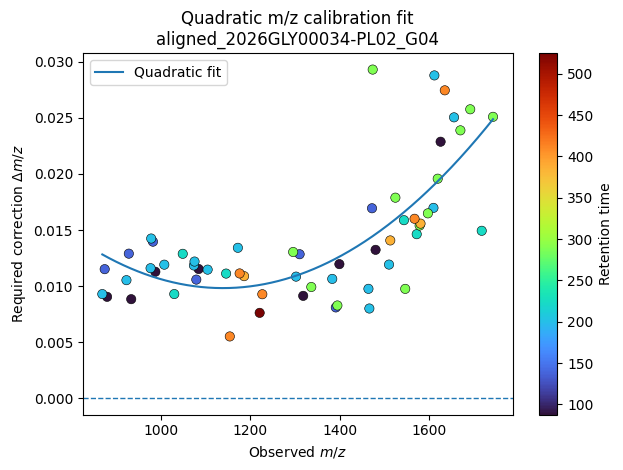

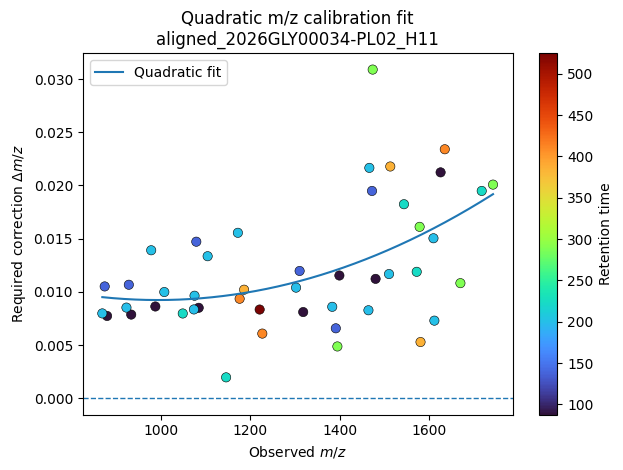

In [124]:
# Loop over calibrants of each mzXML file, then fit and visualize.
for raw_file, calibrants in calibrants_dict.items():
    fit = calibration_fit_quadratic(calibrants)
    figure = plot_calibration_fit_quadratic(calibrants, fit, raw_file)

Overall, the quadratic fits seem plausible. 
But there are some notable outliers. Especially the early eluting
calibrant seem to be outliers and cluster together.

There are also some occasional high m/z outliers.

Next we'll plot the residuals against retention time, with the points
colored by m/z.

In [125]:
def plot_quadratic_calibration_residuals(
    calibrants: list[dict],
    fit: np.ndarray,
    raw_file: str
) -> Figure:
    mz_observed = np.array(
    [
        calibrant["mz_observed"]
        for calibrant in calibrants
    ],
    dtype=float
    )

    mz_delta = np.array(
        [
            calibrant["mz_exact"] - calibrant["mz_observed"]
            for calibrant in calibrants
        ]
    )

    time = np.array(
        [
            calibrant["time"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    # Apply fit to observed m/z values.
    mz_delta_predicted = np.polyval(fit, mz_observed)

    # Calculate residuals.
    residuals = mz_delta - mz_delta_predicted

    # Make figure.
    figure, axis = plt.subplots()
    scatter = axis.scatter(
        time,
        residuals,
        c=mz_observed,
        cmap="plasma",
        s=45,
        edgecolors="black",
        linewidths=0.4
    )
    axis.axhline(0, linewidth=1, linestyle="--")
    axis.set_xlabel("Retention time")
    axis.set_ylabel(r"Residual $\Delta m/z$")
    axis.set_title(f"Quadratic calibration residuals by retention time\n{raw_file}")
    colorbar = figure.colorbar(scatter, ax=axis)
    colorbar.set_label(r"Observed $m/z$")

    figure.tight_layout()

    return figure

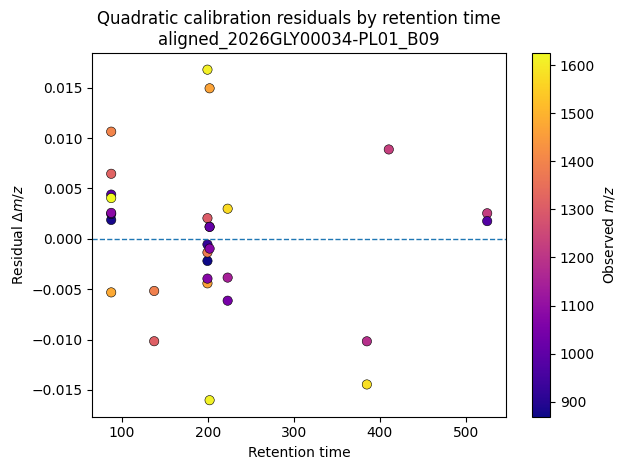

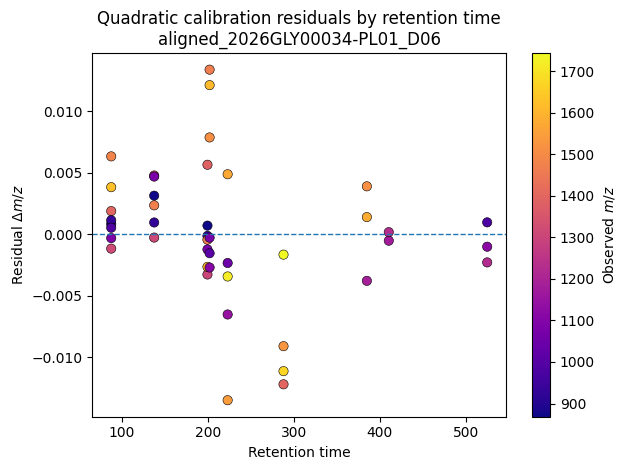

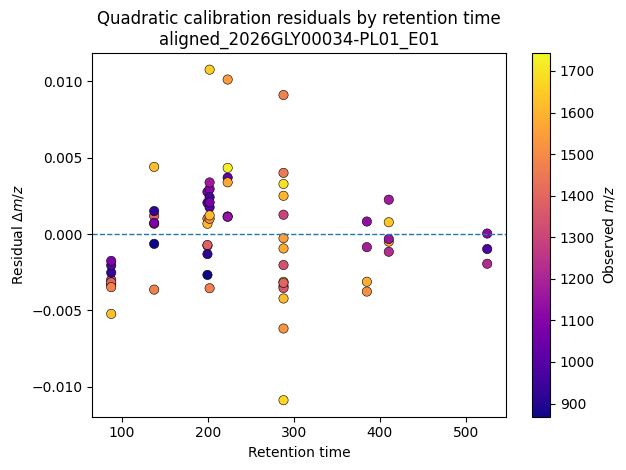

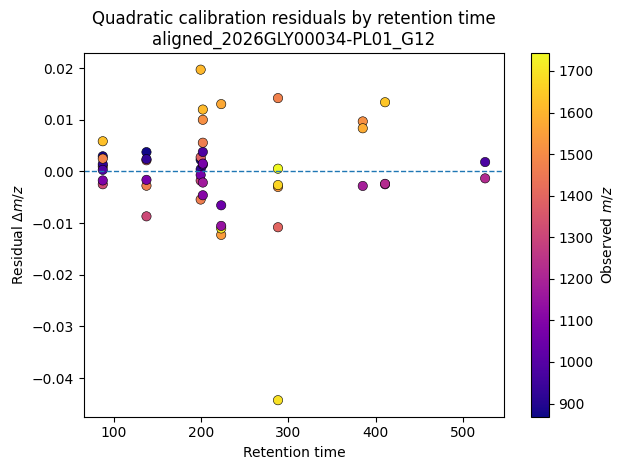

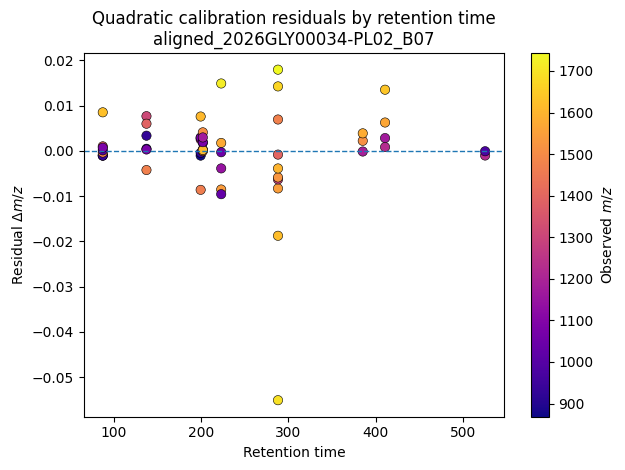

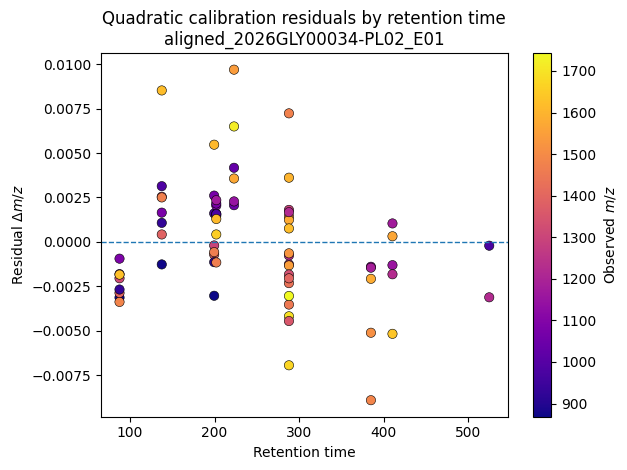

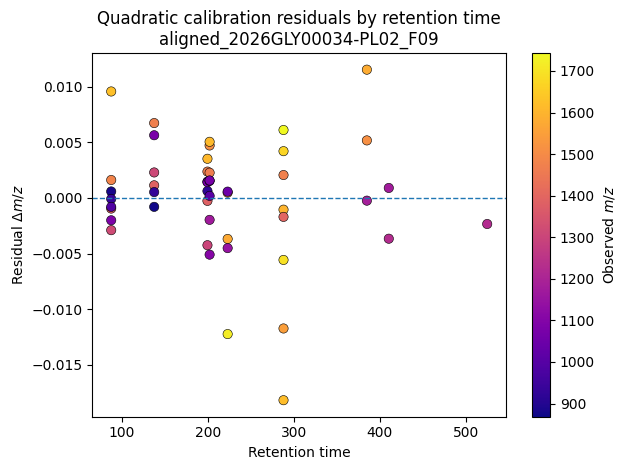

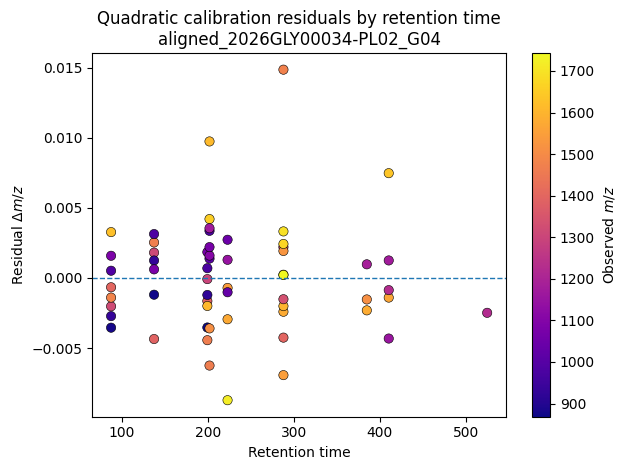

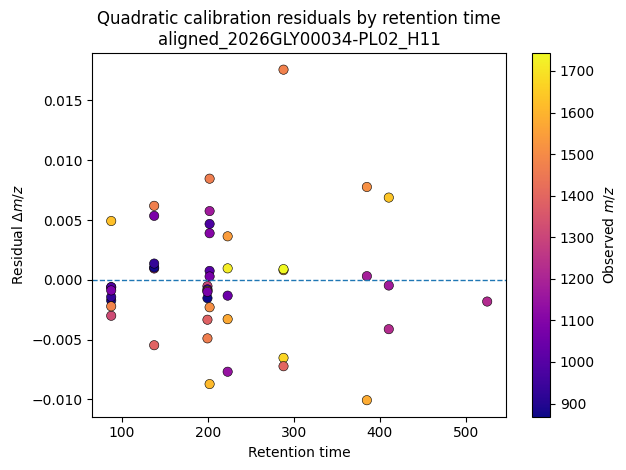

In [126]:
for raw_file, calibrants in calibrants_dict.items():
    fit = calibration_fit_quadratic(calibrants)
    figure = plot_quadratic_calibration_residuals(calibrants, fit, raw_file)

The residuals appear to not be entirely randomly distributed around 0.
Overall, they seem to be a bit higher at earlier retention times.
But there is no clear linear trend and there are clear outliers.

A sensible next step would be to add a linear time term to the model:
$$\Delta m/z = \beta_0 + \beta_1 \times m/z_\text{observed} + \beta_2 \times (m/z_\text{observed})^2 + \beta_3 \times t$$

## Fit including linear retention time term

In [127]:
def calibration_fit_time(calibrants: list[dict]) -> np.ndarray:
    """Fit a quadratic m/z plus linear time calibration model.
    
    The model predicts the required m/z correction:

        mz_exact - mz_observed

    using the model:

        mz_delta = (
            beta_0
            + beta_1 * mz_observed
            + beta_2 * mz_observed**2
            + beta_3 * time
        )
    
    Returns a NumPy array containing the fitted coefficients in the order:
    [quadratic m/z, linear m/z, time, intercept]
    """
    mz_observed = np.array(
        [
            calibrant["mz_observed"] 
            for calibrant in calibrants
        ],
        dtype=float
    )

    mz_delta = np.array(
        [
            calibrant["mz_exact"] - calibrant["mz_observed"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    time = np.array(
        [
            calibrant["time"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    design_matrix = np.column_stack(
        [
            mz_observed**2,
            mz_observed,
            time,
            np.ones_like(mz_observed)
        ]
    )

    fit, _, _, _ = np.linalg.lstsq(
        design_matrix,
        mz_delta,
        rcond=None
    )

    return fit

Before using above fitting function including time, it is useful to do a
regression using the `statsmodels` package which should also give p-values
for the coefficients. Looking at the p-value for time is equivalent to an 
ANOVA comparing the full model and the one without time, because they only
differ by the linear time effect.

In [128]:
import statsmodels.api as sm
from statsmodels.regression.linear_model import RegressionResultsWrapper

def calibration_fit_time_pvals(
    calibrants: list[dict]
) -> RegressionResultsWrapper:
    mz_observed = np.array(
        [
            calibrant["mz_observed"]
            for calibrant in calibrants
        ],
        dtype = float
    )

    mz_delta = np.array(
        [
            calibrant["mz_exact"] - calibrant["mz_observed"]
            for calibrant in calibrants
        ],
        dtype = float
    )

    time = np.array(
        [
            calibrant["time"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    design_matrix = np.column_stack(
        [
            mz_observed,
            mz_observed**2,
            time
        ]
    )

    design_matrix = sm.add_constant(design_matrix)

    return sm.OLS(mz_delta, design_matrix).fit()

In [129]:
for _, calibrants in calibrants_dict.items():
    print(calibration_fit_time_pvals(calibrants).pvalues[3])

0.4913999406085803
0.13842113517127858
0.883854681215898
0.9277929538741994
0.8653085519333101
0.04053324323640453
0.4676456142812141
0.9899684894269627
0.9778152380695684


These p-values indicate that including a linear retention time term can
sometimes improve the fit. But all this tests is whether the time effect
is different from zero, it tells nothing yet about the actual effect.

We'll compare the pre- and post-calibration mass errors of the calibrants
using both models.

In [130]:
def get_calibrant_mass_errors(
    calibrants: list[dict],
    fit_quadratic: np.ndarray,
    fit_time: np.ndarray
):
    mz_observed = np.array(
    [
        calibrant["mz_observed"]
        for calibrant in calibrants
    ],
    dtype = float
    )

    mz_exact = np.array(
        [
            calibrant["mz_exact"]
            for calibrant in calibrants
        ],
        dtype = float
    )

    time = np.array(
        [
            calibrant["time"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    # Correction predicted by quadratic m/z-only model.
    correction_quadratic = np.polyval(
        fit_quadratic, mz_observed
    )

    # Correction predicted by the model including time.
    (
        quadratic_coeff,
        linear_coeff,
        time_coeff,
        intercept
    ) = fit_time

    correction_time = (
        quadratic_coeff * mz_observed**2
        + linear_coeff * mz_observed
        + time_coeff * time
        + intercept
    )

    # Calculate calibrated m/z values
    mz_calibrated_quadratic = mz_observed + correction_quadratic
    mz_calibrated_time = mz_observed + correction_time

    # Calculate pre- and post-calibration mass errors
    mass_error_before_ppm = (mz_observed - mz_exact) / mz_exact * 1e6
    mass_error_quadratic_ppm = (mz_calibrated_quadratic - mz_exact) / mz_exact * 1e6
    mass_error_time_ppm = (mz_calibrated_time - mz_exact) / mz_exact * 1e6

    return pd.DataFrame(
        {
            "mz_exact": mz_exact,
            "mz_observed": mz_observed,
            "time": time,
            "mz_calibrated_quadratic": mz_calibrated_quadratic,
            "mz_calibrated_time": mz_calibrated_time,
            "mass_error_before_ppm": mass_error_before_ppm,
            "mass_error_quadratic_ppm": mass_error_quadratic_ppm,
            "mass_error_time_ppm": mass_error_time_ppm
        }
    )

In [131]:
def plot_calibrant_mass_error_comparison(
    mass_errors: pd.DataFrame,
    raw_file: str
) -> Figure:
    plot_data = mass_errors[
        [
            "mass_error_before_ppm",
            "mass_error_quadratic_ppm",
            "mass_error_time_ppm"
        ]
    ].copy()

    plot_data.columns = [
        "Before",
        "Quadratic",
        "Quadratic + time"
    ]

    figure, axis = plt.subplots()

    for _, row in plot_data.iterrows():
        axis.plot(
            plot_data.columns,
            row,
            marker="o",
            alpha=0.35
        )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    axis.set_ylabel("Mass error (ppm)")

    axis.set_title(f"Pre- and post-calibration mass errors\n{raw_file}")

    figure.tight_layout()

    return figure

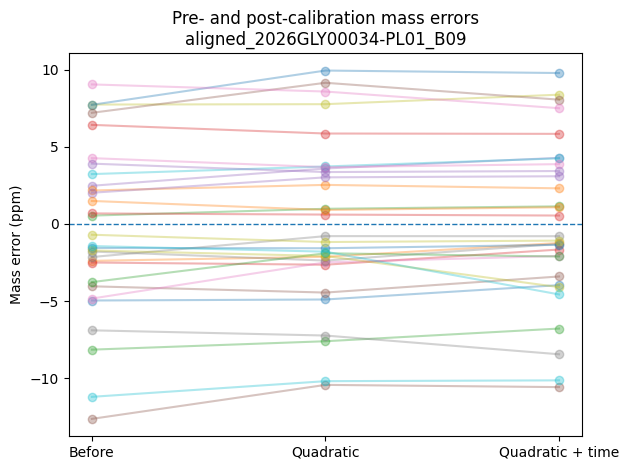

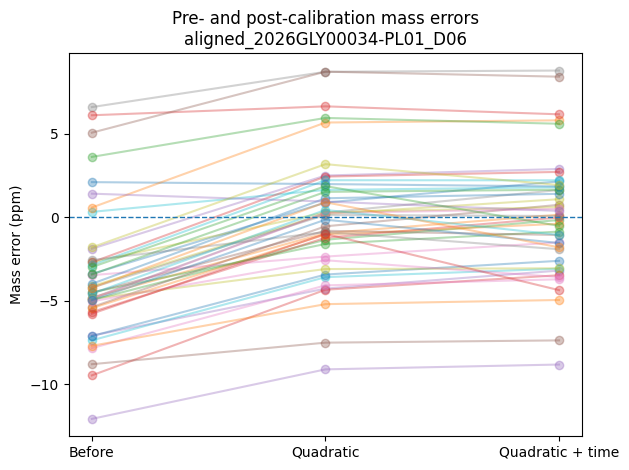

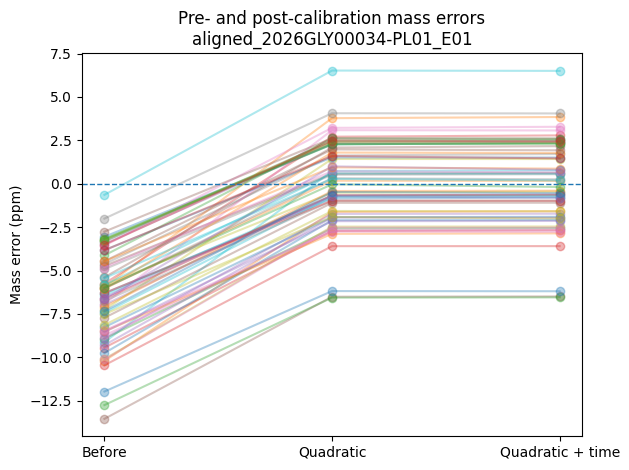

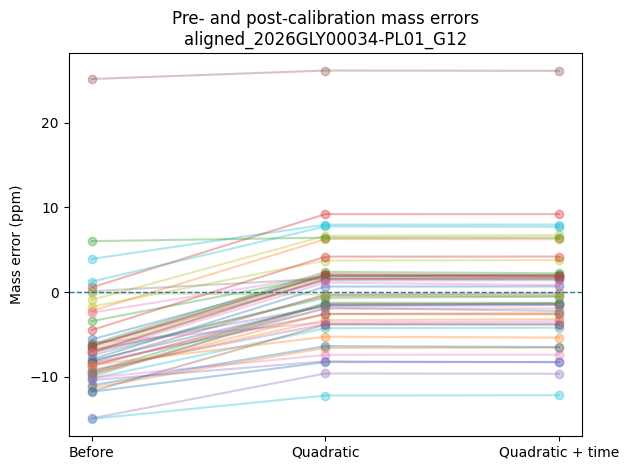

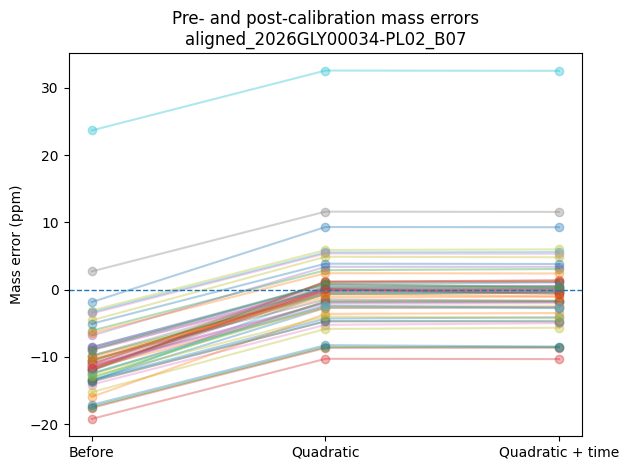

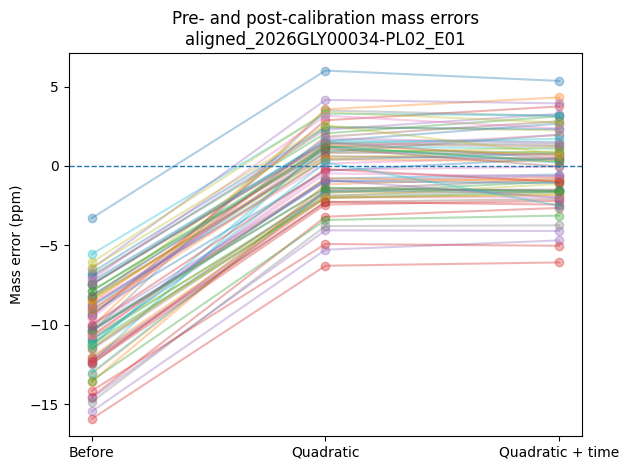

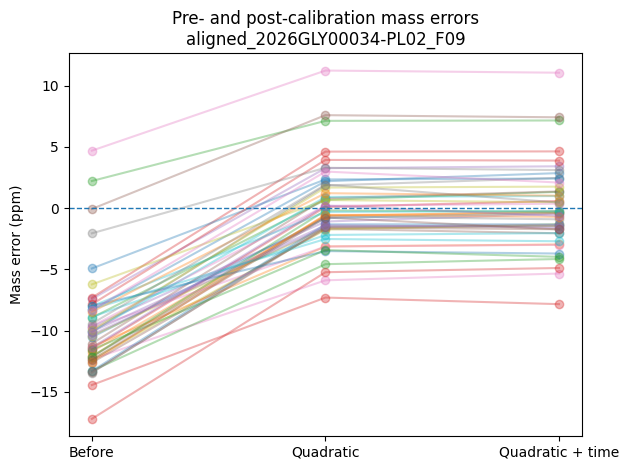

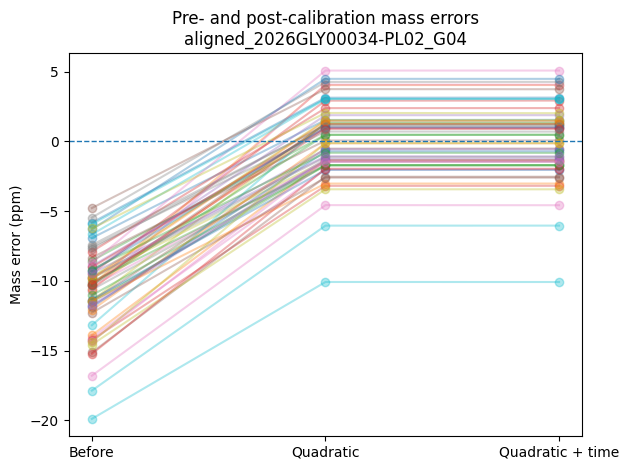

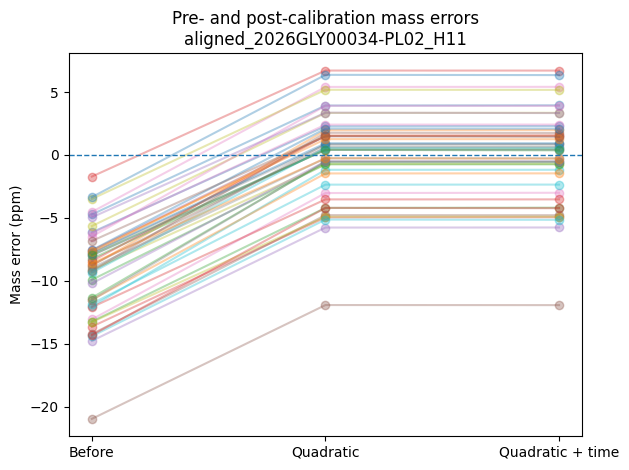

In [132]:
for raw_file, calibrants in calibrants_dict.items():
    fit_quadratic = calibration_fit_quadratic(calibrants)
    fit_time = calibration_fit_time(calibrants)

    mass_errors = get_calibrant_mass_errors(
        calibrants, fit_quadratic, fit_time
    )

    figure = plot_calibrant_mass_error_comparison(
        mass_errors, raw_file
    )

Based on the figures above, the quadratic m/z calibration clearly reduces
the mass errors. Including time seems to have a minimal impact. Sometimes
it improves the mass erros somewhat, and sometimes it makes them a bit worse.
This suggests that a quadratic fit without retention time is sufficient.

What we should still do is compare the post-calibration mass errors from this
new method with the older method where calibration is performed per retention
time range.

In [133]:
comparison_rows = []

for raw_file, calibrants in calibrants_dict.items():
    # Get unique retention times in ascending order
    times = sorted(
        set(cal["time"] for cal in calibrants)
    )

    # New approach: one quadratic fit using all calibrants in the raw file.
    fit_total = calibration_fit_quadratic(calibrants)

    # Old approach: separate quadratic fit for each retention time.
    for time in times:
        calibrants_time = [
            cal for cal in calibrants
            if cal["time"] == time
        ]

        if len(calibrants_time) >= 4:
            fit_time = calibration_fit_quadratic(calibrants_time)
        else:
            fit_time = None
            print(f"Not enough calibrants at {time} s in {raw_file}")

        for calibrant in calibrants_time:
            mz_observed = calibrant["mz_observed"]
            mz_exact = calibrant["mz_exact"]

            # Pre-calibration mass errors
            mass_error_before_ppm = (mz_observed - mz_exact) / mz_exact * 1e6

            # New pooled calibration
            correction_total = np.polyval(fit_total, mz_observed)

            mz_calibrated_total = mz_observed + correction_total

            mass_error_total_ppm = (mz_calibrated_total - mz_exact) / mz_exact * 1e6

            # Old retention-time-specific calibration
            if fit_time is None:
                mz_calibrated_time, mass_error_time_ppm = np.nan, np.nan
            else:
                correction_time = np.polyval(fit_time, mz_observed)
                mz_calibrated_time = mz_observed + correction_time
                mass_error_time_ppm = (mz_calibrated_time - mz_exact) / mz_exact * 1e6

            comparison_rows.append(
                {
                    "raw_file": raw_file,
                    "time": time,
                    "mz_exact": mz_exact,
                    "mz_observed": mz_observed,
                    "n_calibrants_at_time": len(calibrants_time),
                    "old_calibration_available": len(calibrants_time),
                    "mass_error_before_ppm": mass_error_before_ppm,
                    "mass_error_old_local_ppm": mass_error_time_ppm,
                    "mass_error_new_pooled_ppm": mass_error_total_ppm
                }
            )


calibration_comparison = pd.DataFrame(comparison_rows)

Not enough calibrants at 137.5 s in aligned_2026GLY00034-PL01_B09
Not enough calibrants at 223.0 s in aligned_2026GLY00034-PL01_B09
Not enough calibrants at 385.0 s in aligned_2026GLY00034-PL01_B09
Not enough calibrants at 410.5 s in aligned_2026GLY00034-PL01_B09
Not enough calibrants at 525.0 s in aligned_2026GLY00034-PL01_B09
Not enough calibrants at 385.0 s in aligned_2026GLY00034-PL01_D06
Not enough calibrants at 410.5 s in aligned_2026GLY00034-PL01_D06
Not enough calibrants at 525.0 s in aligned_2026GLY00034-PL01_D06
Not enough calibrants at 525.0 s in aligned_2026GLY00034-PL01_E01
Not enough calibrants at 385.0 s in aligned_2026GLY00034-PL01_G12
Not enough calibrants at 410.5 s in aligned_2026GLY00034-PL01_G12
Not enough calibrants at 525.0 s in aligned_2026GLY00034-PL01_G12
Not enough calibrants at 385.0 s in aligned_2026GLY00034-PL02_B07
Not enough calibrants at 525.0 s in aligned_2026GLY00034-PL02_B07
Not enough calibrants at 525.0 s in aligned_2026GLY00034-PL02_E01
Not enough

In [134]:
import matplotlib.colors as mcolors

def plot_calibration_error_comparison(
    calibration_comparison: pd.DataFrame,
    raw_file: str
) -> Figure:
    plot_data = calibration_comparison.loc[
        (
            calibration_comparison["raw_file"] == raw_file
        )
        & (
            calibration_comparison["old_calibration_available"]
        )
    ].copy()

    if plot_data.empty:
        raise ValueError(
            f"No calibrants with both calibration methods for {raw_file}."
        )

    plot_data["absolute_error_before_ppm"] = (
        plot_data["mass_error_before_ppm"].abs()
    )

    plot_data["absolute_error_old_ppm"] = (
        plot_data["mass_error_old_local_ppm"].abs()
    )

    plot_data["absolute_error_new_ppm"] = (
        plot_data["mass_error_new_pooled_ppm"].abs()
    )

    figure, axis = plt.subplots()

    norm = mcolors.Normalize(
        vmin=plot_data["time"].min(),
        vmax=plot_data["time"].max()
    )

    cmap = plt.get_cmap("turbo")

    for _, row in plot_data.iterrows():
        line_color = cmap(norm(row["time"]))

        axis.plot(
            ["Before", "Old local", "New pooled"],
            [
                row["absolute_error_before_ppm"],
                row["absolute_error_old_ppm"],
                row["absolute_error_new_ppm"]
            ],
            marker="o",
            alpha=0.7,
            color=line_color
        )

    axis.set_ylabel("Absolute mass error (ppm)")
    axis.set_title(
        "Absolute mass errors before and after calibration\n"
        f"{raw_file}"
    )

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=norm
    )
    sm.set_array([])

    colorbar = figure.colorbar(sm, ax=axis)
    colorbar.set_label("Retention time")

    figure.tight_layout()

    return figure

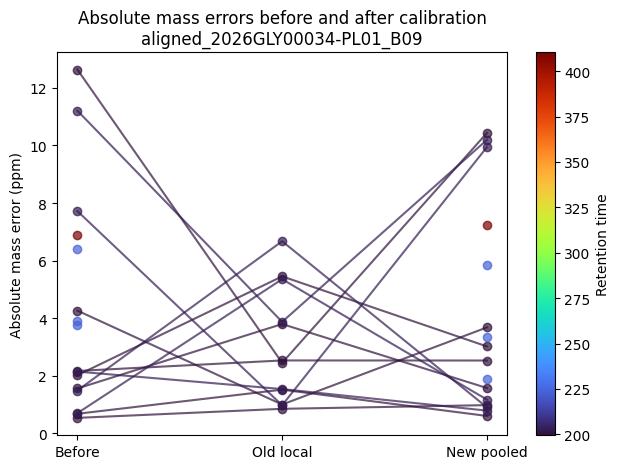

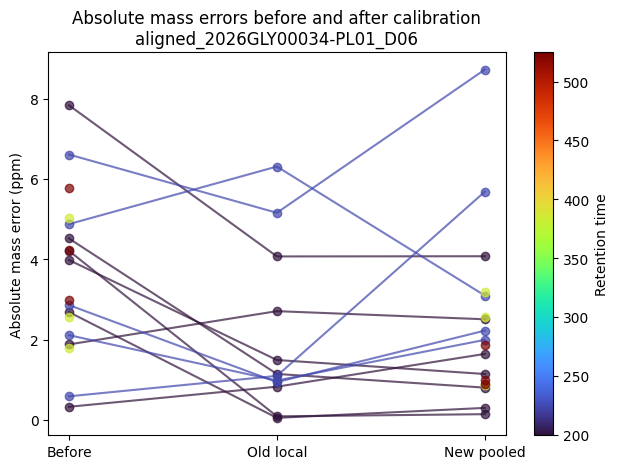

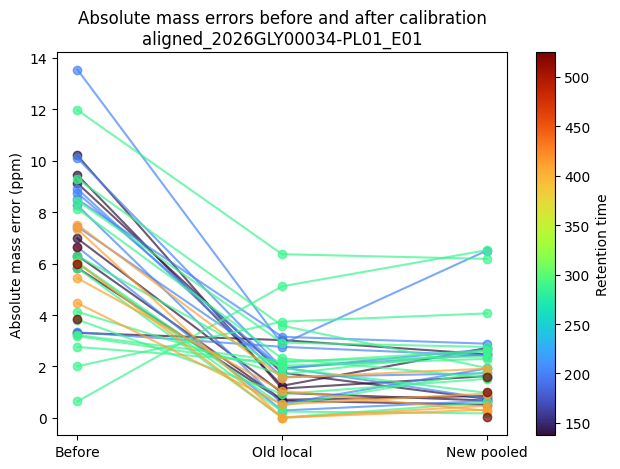

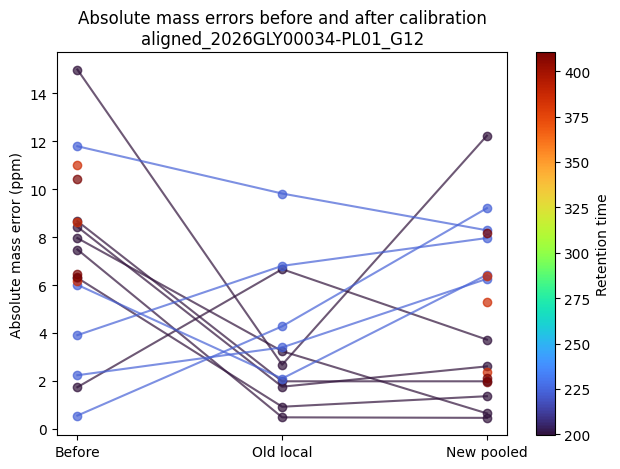

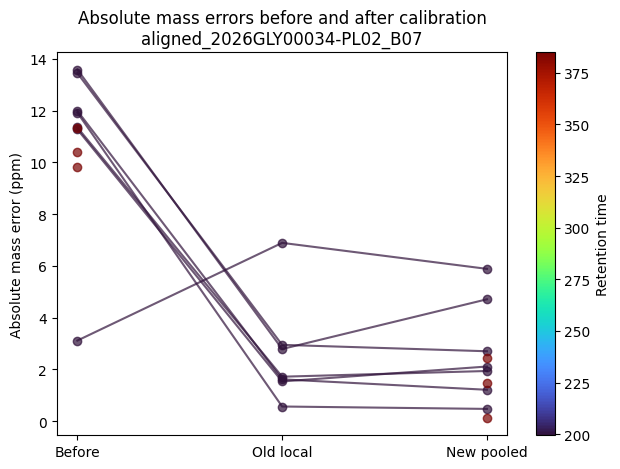

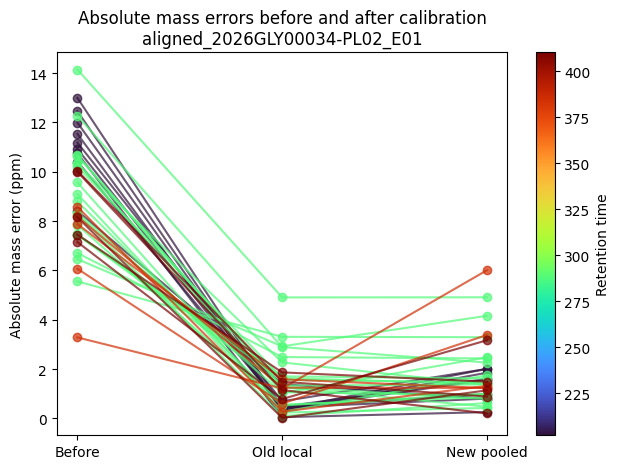

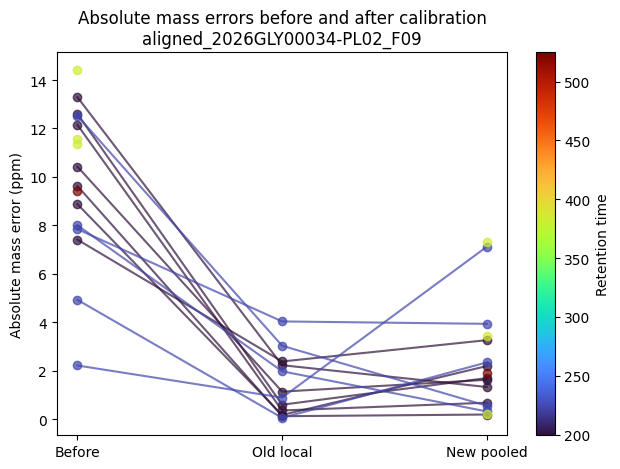

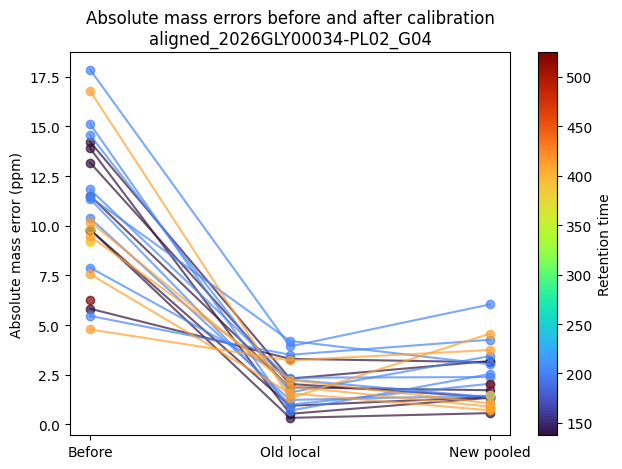

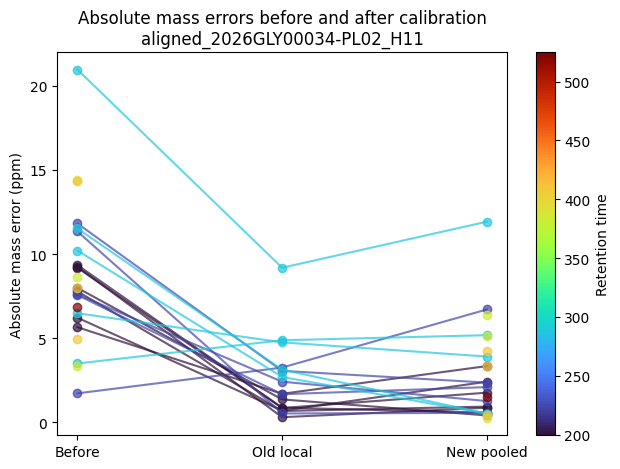

In [135]:
for raw_file in calibration_comparison["raw_file"].unique():
    figure = plot_calibration_error_comparison(
        calibration_comparison=calibration_comparison,
        raw_file=raw_file
    )

The figures suggest that the pooled calibration method is not an improvement
upon the local calibration method. 

My suggestion for calibration would be:
- Model the $\Delta m/z$ values as a function of $m/z_\text{observed}$.
- Collect all calibrants for all retention times with S/N > cut-off.
- Loop over all retention time sum spectra:
    - Collect calibrants for current retention time.
    - If less than MIN_CALIBRANT_NUMBER calibrants, add calibrants from 
    nearest retention time.
    - Recheck count.
    - Continue adding time groups in order of decreasing distance from the
    target time.
        - EDGE CASE: if two groups are equally near, add both.
    - Stop once MIN_CALIBRANT_NUMBER is reached and fit the quadratric model.
    - If the entire file has fewer than four calibrant, leave uncalibrated.